# Capítulo 2 — Tokens e Token Embeddings (por questões)
Resolução de questões referentes ao capítulo 2.

Cada questão tem: **Objetivo** + **Código**.


## Questão 0 — Setup

**Objetivo:** importar libs e escolher CPU/GPU.


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


---

## Questão 1 — Carregar modelo e tokenizer

**Objetivo:** carregar `tokenizer` + `model` do mesmo checkpoint.


In [ ]:
model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

print("Modelo:", model_name)
print("Vocab size:", tokenizer.vocab_size)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo: bert-base-uncased
Vocab size: 30522


---

## Questão 2 — Texto → tokens

**Objetivo:** ver como o texto é quebrado em subpalavras (tokens).


In [ ]:
text = "I love machine learning"
tokens = tokenizer.tokenize(text)

print("Texto:", text)
print("Tokens:", tokens)
print("Qtd. tokens:", len(tokens))

Texto: I love machine learning
Tokens: ['i', 'love', 'machine', 'learning']
Qtd. tokens: 4


---

## Questão 3 — Tokens → IDs

**Objetivo:** converter tokens em números (IDs do vocabulário).


In [ ]:
ids = tokenizer.convert_tokens_to_ids(tokens)

print("Tokens:", tokens)
print("IDs:", ids)

print("\nToken -> ID")
for t, i in zip(tokens, ids):
    print(f"{t:>12} -> {i}")

Tokens: ['i', 'love', 'machine', 'learning']
IDs: [1045, 2293, 3698, 4083]

Token -> ID
           i -> 1045
        love -> 2293
     machine -> 3698
    learning -> 4083


---

## Questão 4 — Embeddings por token (contextualizados)

**Objetivo:** obter `last_hidden_state` (um vetor por token).


In [ ]:
text = "I love artificial intelligence"
inputs = tokenizer(text, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

token_embeddings = outputs.last_hidden_state
print("last_hidden_state shape:", token_embeddings.shape)

last_hidden_state shape: torch.Size([1, 6, 768])


---

## Questão 5 — Embedding de frase (baseline: mean pooling)

**Objetivo:** gerar 1 vetor para a frase inteira usando média simples.


In [ ]:
sentence_embedding = token_embeddings.mean(dim=1)
print("sentence_embedding shape:", sentence_embedding.shape)

sentence_embedding shape: torch.Size([1, 768])


---

## Questão 6 — Similaridade entre frases (cosine)

**Objetivo:** medir o quanto duas frases são parecidas semanticamente (aprox.).


In [ ]:
import torch.nn.functional as F

def embed_sentence_mean(sentence: str):
    inp = tokenizer(sentence, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(**inp).last_hidden_state
    return out.mean(dim=1)

s1 = "I love AI"
s2 = "I enjoy artificial intelligence"

e1 = embed_sentence_mean(s1)
e2 = embed_sentence_mean(s2)

sim = F.cosine_similarity(e1, e2).item()
print("s1:", s1)
print("s2:", s2)
print("cosine similarity:", sim)

s1: I love AI
s2: I enjoy artificial intelligence
cosine similarity: 0.6047418713569641


---

## Questão 7 — Recomendação simples por similaridade

**Objetivo:** ranquear itens mais parecidos com uma consulta (query).


In [ ]:
import torch.nn.functional as F

items = [
    "I love rock music",
    "Heavy metal is great",
    "I enjoy cooking",
    "I like reading books",
    "I listen to jazz on weekends",
]

item_embs = [embed_sentence_mean(x) for x in items]

query = "I like metal music"
q_emb = embed_sentence_mean(query)

scores = []
for it, emb in zip(items, item_embs):
    score = F.cosine_similarity(q_emb, emb).item()
    scores.append((it, score))

for it, sc in sorted(scores, key=lambda x: x[1], reverse=True):
    print(f"{sc:.4f}  |  {it}")

0.8953  |  I love rock music
0.8411  |  I like reading books
0.7874  |  Heavy metal is great
0.7750  |  I enjoy cooking
0.6827  |  I listen to jazz on weekends


---

## Questão 8 — Matriz de similaridade (visual)

**Objetivo:** criar uma matriz N×N de similaridade entre frases.


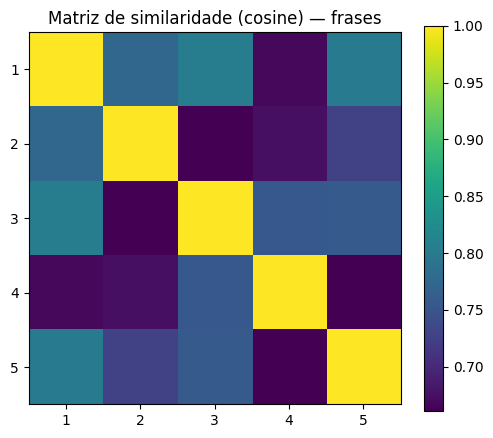

Legenda:
1: I love rock music
2: Metal music is loud
3: I love cooking pasta
4: Baking cakes is fun
5: I read science books


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch

sentences = [
    "I love rock music",
    "Metal music is loud",
    "I love cooking pasta",
    "Baking cakes is fun",
    "I read science books",
]

embs = [embed_sentence_masked(s) for s in sentences]
embs = torch.cat(embs, dim=0)

norm = F.normalize(embs, p=2, dim=1)
sim_matrix = (norm @ norm.T).detach().cpu().numpy()

plt.figure(figsize=(6, 5))
plt.imshow(sim_matrix)
plt.xticks(range(len(sentences)), range(1, len(sentences)+1))
plt.yticks(range(len(sentences)), range(1, len(sentences)+1))
plt.title("Matriz de similaridade (cosine) — frases")
plt.colorbar()
plt.show()

print("Legenda:")
for i, s in enumerate(sentences, start=1):
    print(f"{i}: {s}")